# R7 — Fork/Mast Segmentation with YOLO26 on Kaggle

Notebook này train **YOLO26 Instance Segmentation** cho 2 class phục vụ R7:

- `forks`
- `mast`

Dataset gốc từ Roboflow có 16 class và 266 frame nguồn. Bản export v2 có 645 ảnh train vì mỗi frame train được nhân thành 3 biến thể photometric. Notebook sẽ:

1. Kiểm tra GPU.
2. Cài phiên bản `ultralytics` đã kiểm thử.
3. Tìm đúng dataset `forklifts-icya5` trong `/kaggle/input`.
4. Xác nhận class gốc `forks=5`, `mast=11`.
5. Audit **toàn bộ** ảnh/label/polygon và phát hiện leakage.
6. Split lại theo chuỗi/xe (group-aware 7/1/1), không chia frame ngẫu nhiên.
7. Lọc/remap còn 2 class và lưu manifest truy vết.
8. Thống kê, visualize positive lẫn negative sample.
9. Fine-tune `yolo26s-seg.pt` với cấu hình phù hợp mask mảnh.
10. Chọn checkpoint theo **mask mAP50-95**, validate/test và export artifact.

> **Kaggle:** bật GPU tại `Settings → Accelerator → GPU`.

> Nếu muốn chạy thử nhanh hơn, đổi `MODEL_NAME = "yolo26n-seg.pt"`. Test split chỉ chạy sau khi đã chốt cấu hình trên validation.

## 1–2. Kiểm tra GPU và cài dependencies

In [1]:
import os
import sys
import subprocess
import platform
import shutil

print("Python:", sys.version)
print("Platform:", platform.platform())

nvidia_smi = shutil.which("nvidia-smi")
if nvidia_smi:
    subprocess.run([nvidia_smi], check=False)
else:
    print("WARNING: nvidia-smi không có trong PATH.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Tue Aug 11 04:53:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                 

In [2]:
# Pin để cùng notebook cho cùng hành vi train/fitness/export.
%pip install -q "ultralytics==8.4.116" "pyyaml>=6.0.2,<7"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 3. Import và kiểm tra phiên bản

In [3]:
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import csv
import hashlib
import json
import math
import re
import random
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import ultralytics
from ultralytics import YOLO

EXPECTED_ULTRALYTICS_VERSION = "8.4.116"
print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if ultralytics.__version__ != EXPECTED_ULTRALYTICS_VERSION:
    raise RuntimeError(
        f"Expected ultralytics {EXPECTED_ULTRALYTICS_VERSION}, nhận "
        f"{ultralytics.__version__}. Restart kernel rồi Run All."
    )

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print("GPU memory (GB):", round(props.total_memory / 1024**3, 2))
else:
    print("WARNING: GPU chưa được bật.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.116
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 14.56


## 4. Tìm đúng dataset Roboflow trong `/kaggle/input`

Notebook ưu tiên metadata `roboflow.project=Forklifts-icya5`, đồng thời bắt buộc đủ 3 split và 2 class mục tiêu. Nếu có nhiều candidate hợp lệ, đặt `SOURCE_YAML_OVERRIDE` để tránh chọn nhầm.

In [4]:
INPUT_ROOT = Path(os.environ.get("KAGGLE_INPUT_PATH", "/kaggle/input"))
WORK_ROOT = Path(os.environ.get("KAGGLE_WORKING_PATH", "/kaggle/working"))
SOURCE_YAML_OVERRIDE = None
EXPECTED_PROJECT = "forklifts-icya5"
TARGET_CLASS_NAMES = {"forks", "mast"}
SPLITS = ("train", "valid", "test")

if not INPUT_ROOT.is_dir():
    raise FileNotFoundError(f"Không tồn tại input root: {INPUT_ROOT}")

yaml_candidates = (
    [Path(SOURCE_YAML_OVERRIDE)]
    if SOURCE_YAML_OVERRIDE is not None
    else sorted(INPUT_ROOT.rglob("data.yaml"))
)
print(f"Found {len(yaml_candidates)} data.yaml file(s):")
for p in yaml_candidates:
    print(" -", p)

def normalize_names(raw_names):
    if isinstance(raw_names, list):
        return {i: str(name) for i, name in enumerate(raw_names)}
    if isinstance(raw_names, dict):
        parsed = {int(k): str(v) for k, v in raw_names.items()}
        if sorted(parsed) != list(range(len(parsed))):
            raise ValueError(f"Class IDs không liên tục: {sorted(parsed)}")
        return parsed
    raise TypeError("`names` phải là list hoặc dict.")

matches = []
rejected = []
for yaml_path in yaml_candidates:
    try:
        with open(yaml_path, "r", encoding="utf-8") as f:
            cfg = yaml.safe_load(f)

        id_to_name_candidate = normalize_names(cfg.get("names"))
        names_set = set(id_to_name_candidate.values())
        root = yaml_path.parent
        split_ok = all(
            (root / split / "images").is_dir()
            and (root / split / "labels").is_dir()
            for split in SPLITS
        )
        if TARGET_CLASS_NAMES.issubset(names_set) and split_ok:
            project = str(cfg.get("roboflow", {}).get("project", "")).lower()
            matches.append((yaml_path, cfg, project))
        else:
            rejected.append((yaml_path, "thiếu class hoặc cấu trúc split"))
    except Exception as exc:
        rejected.append((yaml_path, f"{type(exc).__name__}: {exc}"))

preferred = [item for item in matches if item[2] == EXPECTED_PROJECT]
matches = preferred or matches

if not matches:
    raise FileNotFoundError(
        f"Không tìm thấy data.yaml hợp lệ trong {INPUT_ROOT}. Rejected: {rejected[:5]}"
    )
if len(matches) > 1:
    raise RuntimeError(
        "Có nhiều dataset phù hợp; hãy đặt SOURCE_YAML_OVERRIDE:\n"
        + "\n".join(f" - {item[0]}" for item in matches)
    )

SOURCE_YAML, SOURCE_CFG, _ = matches[0]
SOURCE_ROOT = SOURCE_YAML.parent

print("\nSelected data.yaml:", SOURCE_YAML)
print("Dataset root:", SOURCE_ROOT)
print("Roboflow metadata:", SOURCE_CFG.get("roboflow", {}))
print("Original names:", SOURCE_CFG["names"])

Found 1 data.yaml file(s):
 - /kaggle/input/datasets/carlostran/forklifts-cv-data/data.yaml

Selected data.yaml: /kaggle/input/datasets/carlostran/forklifts-cv-data/data.yaml
Dataset root: /kaggle/input/datasets/carlostran/forklifts-cv-data
Roboflow metadata: {'workspace': 'abdul-nizar-kntam', 'project': 'forklifts-icya5', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/abdul-nizar-kntam/forklifts-icya5/dataset/2'}
Original names: ['backrest', 'backsideCab', 'counterWeight', 'engineCompartment', 'exhaust', 'forks', 'frame', 'frontsideCab', 'fuelTank', 'leftsideCab', 'light', 'mast', 'mirror', 'overheadGuard', 'rightsideCab', 'tire']


## 5. Xác nhận cấu trúc dataset và class ID

Với dataset `Forklifts v2`, dự kiến:

- `forks = 5`
- `mast = 11`

Cell này lấy ID trực tiếp từ YAML thay vì hard-code.

In [5]:
id_to_name = normalize_names(SOURCE_CFG["names"])
if len(set(id_to_name.values())) != len(id_to_name):
    raise ValueError("Tên class trong YAML không được trùng nhau.")

name_to_id = {v: k for k, v in id_to_name.items()}

FORK_OLD_ID = name_to_id["forks"]
MAST_OLD_ID = name_to_id["mast"]
CLASS_MAP = {FORK_OLD_ID: 0, MAST_OLD_ID: 1}
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("forks old ID:", FORK_OLD_ID)
print("mast old ID :", MAST_OLD_ID)

SOURCE_DIRS = {}
for split in SPLITS:
    img_dir = SOURCE_ROOT / split / "images"
    lbl_dir = SOURCE_ROOT / split / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        raise FileNotFoundError(
            f"Thiếu {split}/images hoặc {split}/labels trong {SOURCE_ROOT}"
        )
    SOURCE_DIRS[split] = {"images": img_dir, "labels": lbl_dir}
    print(f"{split:5s} | images={img_dir} | labels={lbl_dir}")

forks old ID: 5
mast old ID : 11
train | images=/kaggle/input/datasets/carlostran/forklifts-cv-data/train/images | labels=/kaggle/input/datasets/carlostran/forklifts-cv-data/train/labels
valid | images=/kaggle/input/datasets/carlostran/forklifts-cv-data/valid/images | labels=/kaggle/input/datasets/carlostran/forklifts-cv-data/valid/labels
test  | images=/kaggle/input/datasets/carlostran/forklifts-cv-data/test/images | labels=/kaggle/input/datasets/carlostran/forklifts-cv-data/test/labels


## 6. Audit toàn bộ dataset và phát hiện leakage

YOLO segmentation label có dạng:

```text
class_id x1 y1 x2 y2 x3 y3 ...
```

Mỗi object phải có ít nhất 3 điểm polygon, tức ít nhất **7 token** gồm class ID + 6 tọa độ. Cell dưới quét cả 3 split: image/label pairing, parse số, class range, tọa độ hữu hạn trong `[0,1]`, polygon không suy biến, exact duplicate và source/group overlap.

> Dataset v2 chia các frame liền kề của cùng 9 chuỗi vào cả train/valid/test. Đây là **scene leakage**, dù không có filename nguồn trùng trực tiếp. Cell tạo dataset phía sau sẽ split lại theo `series_id`.

In [6]:
ROBOFLOW_MARKER = ".rf."
SERIES_RE = re.compile(r"^(?P<series>.+)_\d+_(?:jpg|jpeg|png)$", re.IGNORECASE)

def source_id_from_path(image_path):
    return image_path.name.split(ROBOFLOW_MARKER, 1)[0]

def series_id_from_source_id(source_id):
    match = SERIES_RE.match(source_id)
    if not match:
        raise ValueError(f"Không suy ra được series_id từ: {source_id}")
    return match.group("series")

def polygon_area(points):
    x, y = points[:, 0], points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def label_geometry_signature(label_path):
    objects = []
    for raw_line in label_path.read_text(encoding="utf-8").splitlines():
        parts = raw_line.strip().split()
        if not parts:
            continue
        cls_id = int(float(parts[0]))
        points = np.asarray(parts[1:], dtype=np.float64).reshape(-1, 2)
        if len(points) > 3 and np.allclose(points[0], points[-1], rtol=0, atol=1e-12):
            points = points[:-1]
        # Không phụ thuộc điểm bắt đầu/hướng duyệt polygon hoặc thứ tự object.
        vertices = tuple(sorted((round(float(x), 10), round(float(y), 10)) for x, y in points))
        objects.append((cls_id, vertices))
    return tuple(sorted(objects))

problems = []
source_records = defaultdict(list)
hash_locations = defaultdict(list)
series_by_original_split = {}
split_audit = {}
checked_lines = 0
closed_polygons = 0

for split in SPLITS:
    image_dir = SOURCE_DIRS[split]["images"]
    label_dir = SOURCE_DIRS[split]["labels"]
    image_paths = sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )
    label_paths = sorted(label_dir.glob("*.txt"))
    image_stems = {p.stem for p in image_paths}
    label_stems = {p.stem for p in label_paths}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)
    if missing_labels:
        problems.append(f"{split}: {len(missing_labels)} ảnh thiếu label")
    if orphan_labels:
        problems.append(f"{split}: {len(orphan_labels)} orphan label")

    class_objects = Counter()
    target_images = Counter()
    dimensions = Counter()
    series_ids = set()

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        source_id = source_id_from_path(image_path)
        try:
            series_id = series_id_from_source_id(source_id)
        except ValueError as exc:
            problems.append(str(exc))
            series_id = source_id
        series_ids.add(series_id)

        try:
            with Image.open(image_path) as image:
                dimensions[image.size] += 1
                image.verify()
        except Exception as exc:
            problems.append(f"Corrupt image {image_path}: {exc}")

        digest = hashlib.sha256(image_path.read_bytes()).hexdigest()
        hash_locations[digest].append((split, image_path.name))
        source_records[source_id].append({
            "image": image_path,
            "label": label_path,
            "original_split": split,
            "series_id": series_id,
        })

        classes_in_image = set()
        if not label_path.exists():
            continue
        for line_no, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
            parts = raw_line.strip().split()
            if not parts:
                continue
            checked_lines += 1
            location = f"{label_path.name}:{line_no}"

            if len(parts) < 7 or len(parts) % 2 == 0:
                problems.append(f"{location}: cần class + >=3 cặp XY, nhận {len(parts)} token")
                continue
            try:
                cls_float = float(parts[0])
                coords = np.asarray(parts[1:], dtype=np.float64)
            except ValueError as exc:
                problems.append(f"{location}: không parse được số ({exc})")
                continue
            if not math.isfinite(cls_float) or not cls_float.is_integer():
                problems.append(f"{location}: class ID không phải số nguyên ({parts[0]})")
                continue
            cls_id = int(cls_float)
            if cls_id not in id_to_name:
                problems.append(f"{location}: class ID ngoài range ({cls_id})")
            if not np.isfinite(coords).all():
                problems.append(f"{location}: tọa độ NaN/Inf")
                continue
            if np.any((coords < 0.0) | (coords > 1.0)):
                problems.append(f"{location}: tọa độ ngoài [0,1]")

            points = coords.reshape(-1, 2)
            if len(np.unique(points, axis=0)) < 3 or polygon_area(points) <= 1e-10:
                problems.append(f"{location}: polygon suy biến")
            if len(points) > 3 and np.allclose(points[0], points[-1], rtol=0, atol=1e-12):
                closed_polygons += 1

            class_objects[cls_id] += 1
            classes_in_image.add(cls_id)

        for cls_id in classes_in_image:
            target_images[cls_id] += int(cls_id in CLASS_MAP)

    series_by_original_split[split] = series_ids
    split_audit[split] = {
        "images": len(image_paths),
        "labels": len(label_paths),
        "objects": sum(class_objects.values()),
        "fork_objects": class_objects[FORK_OLD_ID],
        "mast_objects": class_objects[MAST_OLD_ID],
        "fork_images": target_images[FORK_OLD_ID],
        "mast_images": target_images[MAST_OLD_ID],
        "dimensions": dict(dimensions),
    }

for digest, locations in hash_locations.items():
    if len({split for split, _ in locations}) > 1:
        problems.append(f"Exact duplicate xuyên split: {locations}")

for source_id, records in source_records.items():
    original_splits = {record["original_split"] for record in records}
    if len(original_splits) > 1:
        problems.append(f"Source {source_id} nằm ở nhiều split: {sorted(original_splits)}")
    label_signatures = {label_geometry_signature(record["label"]) for record in records}
    if len(label_signatures) > 1:
        problems.append(f"Các augmentation của {source_id} có label khác nhau")

for left, right in combinations(SPLITS, 2):
    overlap = series_by_original_split[left] & series_by_original_split[right]
    if overlap:
        print(f"WARNING scene leakage {left}<->{right}: {sorted(overlap)}")

within_split_duplicate_groups = sum(
    len(locations) > 1 and len({split for split, _ in locations}) == 1
    for locations in hash_locations.values()
)
variant_distribution = Counter(len(records) for records in source_records.values())

print("\nAudit by original split:")
for split, report in split_audit.items():
    print(split, report)
print("Polygon lines checked:", checked_lines)
print("Closed polygons (điểm cuối lặp điểm đầu):", closed_polygons)
print("Unique source frames:", len(source_records))
print("Variants per source frame:", dict(sorted(variant_distribution.items())))
print("Within-split exact duplicate groups:", within_split_duplicate_groups)

if problems:
    print("\nFirst audit errors:")
    for problem in problems[:20]:
        print(" -", problem)
    raise ValueError(f"Dataset audit thất bại với {len(problems)} lỗi.")

SOURCE_RECORDS = dict(source_records)
SOURCE_AUDIT = split_audit
print("OK: toàn bộ ảnh và polygon hợp lệ; sẽ sửa scene leakage bằng group split.")

WARNING scene leakage train<->valid: ['AE50', 'AM50', 'AX50', 'BBX50', 'BX50', 'CX50', 'FH100-160', 'FH35-50', 'FH70-80']
WARNING scene leakage train<->test: ['AE50', 'AM50', 'AX50', 'BBX50', 'BX50', 'CX50', 'FH35-50', 'FH70-80']
WARNING scene leakage valid<->test: ['AE50', 'AM50', 'AX50', 'BBX50', 'BX50', 'CX50', 'FH35-50', 'FH70-80']

Audit by original split:
train {'images': 645, 'labels': 645, 'objects': 6642, 'fork_objects': 768, 'mast_objects': 576, 'fork_images': 393, 'mast_images': 576, 'dimensions': {(640, 640): 645}}
valid {'images': 26, 'labels': 26, 'objects': 260, 'fork_objects': 25, 'mast_objects': 21, 'fork_images': 14, 'mast_images': 21, 'dimensions': {(640, 640): 26}}
test {'images': 25, 'labels': 25, 'objects': 262, 'fork_objects': 32, 'mast_objects': 23, 'fork_images': 17, 'mast_images': 23, 'dimensions': {(640, 640): 25}}
Polygon lines checked: 7164
Closed polygons (điểm cuối lặp điểm đầu): 7164
Unique source frames: 266
Variants per source frame: {1: 51, 3: 215}
Wi

## 7. Group split rồi tạo dataset R7 `forks` + `mast`

Mapping mới:

```text
0 = forks
1 = mast
```

Notebook **không giữ split Roboflow cũ** vì các frame gần nhau của cùng chuỗi đang leakage. Chín `series_id` được shuffle cố định bằng seed 42 rồi chia 7 train / 1 valid / 1 test. Mọi frame của một series chỉ xuất hiện trong đúng một split.

- Train giữ các photometric variants có nội dung khác nhau.
- Valid/test chỉ giữ một variant có exposure gần median cho mỗi frame nguồn. Đây là workaround cho bản export augmented; tốt nhất vẫn là re-export bản **không offline augmentation**.
- Ảnh không chứa `forks`/`mast` trở thành **negative sample** với label rỗng; hãy kiểm tra trực quan ở cell phía sau để loại false-negative annotation.

In [7]:
GROUP_SPLIT_SEED = 42
VAL_GROUP_FRACTION = 0.10
TEST_GROUP_FRACTION = 0.10
KEEP_TRAIN_VARIANTS = True

resolved_work_root = WORK_ROOT.resolve()
resolved_work_root.mkdir(parents=True, exist_ok=True)
DST_ROOT = (resolved_work_root / "forklift_r7_grouped").resolve()
BUILD_ROOT = (resolved_work_root / "forklift_r7_grouped_build").resolve()
for target in (DST_ROOT, BUILD_ROOT):
    if target.parent != resolved_work_root:
        raise RuntimeError(f"Unsafe output path: {target}")

all_series = sorted({
    records[0]["series_id"] for records in SOURCE_RECORDS.values()
})
if len(all_series) < 3:
    raise ValueError(f"Cần ít nhất 3 series để group split, nhận {all_series}")

shuffled_series = all_series.copy()
random.Random(GROUP_SPLIT_SEED).shuffle(shuffled_series)
n_test = max(1, round(len(all_series) * TEST_GROUP_FRACTION))
n_valid = max(1, round(len(all_series) * VAL_GROUP_FRACTION))
if n_test + n_valid >= len(all_series):
    raise ValueError("Tỷ lệ group split không còn group cho train.")

GROUP_ASSIGNMENT = {
    "train": set(shuffled_series[: -(n_valid + n_test)]),
    "valid": set(shuffled_series[-(n_valid + n_test) : -n_test]),
    "test": set(shuffled_series[-n_test:]),
}
series_to_split = {
    series_id: split
    for split, series_ids in GROUP_ASSIGNMENT.items()
    for series_id in series_ids
}
if set(series_to_split) != set(all_series):
    raise AssertionError("Group assignment không phủ đúng toàn bộ series.")

def image_exposure(image_path):
    with Image.open(image_path) as image:
        gray = image.convert("L").resize((64, 64), Image.Resampling.BILINEAR)
        return float(np.asarray(gray, dtype=np.float32).mean())

def choose_eval_record(records):
    if len(records) == 1:
        return records[0]
    scored = [(record, image_exposure(record["image"])) for record in records]
    median_exposure = float(np.median([score for _, score in scored]))
    return min(
        scored,
        key=lambda item: (abs(item[1] - median_exposure), item[0]["image"].name),
    )[0]

def unique_content_records(records):
    unique = []
    seen_hashes = set()
    for record in sorted(records, key=lambda item: item["image"].name):
        digest = hashlib.sha256(record["image"].read_bytes()).hexdigest()
        if digest not in seen_hashes:
            seen_hashes.add(digest)
            unique.append(record)
    return unique

def remap_target_lines(label_path):
    remapped = []
    for raw_line in label_path.read_text(encoding="utf-8").splitlines():
        parts = raw_line.strip().split()
        if not parts:
            continue
        old_cls = int(float(parts[0]))  # Đã được audit strict ở cell trước.
        if old_cls not in CLASS_MAP:
            continue
        coord_tokens = parts[1:]
        # YOLO tự đóng polygon; bỏ điểm cuối nếu lặp lại điểm đầu.
        if len(coord_tokens) >= 8:
            first = np.asarray(coord_tokens[:2], dtype=float)
            last = np.asarray(coord_tokens[-2:], dtype=float)
            if np.allclose(first, last, rtol=0, atol=1e-12):
                coord_tokens = coord_tokens[:-2]
        remapped.append(f"{CLASS_MAP[old_cls]} {' '.join(coord_tokens)}")
    return remapped

if BUILD_ROOT.exists():
    shutil.rmtree(BUILD_ROOT)
for split in SPLITS:
    (BUILD_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (BUILD_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

manifest_rows = []
build_counts = Counter()
for source_id in sorted(SOURCE_RECORDS):
    records = SOURCE_RECORDS[source_id]
    series_id = records[0]["series_id"]
    dst_split = series_to_split[series_id]
    if dst_split == "train" and KEEP_TRAIN_VARIANTS:
        selected_records = unique_content_records(records)
    else:
        selected_records = [choose_eval_record(records)]

    for record in selected_records:
        image_path = record["image"]
        label_path = record["label"]
        dst_image = BUILD_ROOT / dst_split / "images" / image_path.name
        dst_label = BUILD_ROOT / dst_split / "labels" / f"{image_path.stem}.txt"
        if dst_image.exists() or dst_label.exists():
            raise FileExistsError(f"Tên file đích bị trùng: {image_path.name}")

        shutil.copy2(image_path, dst_image)
        output_lines = remap_target_lines(label_path)
        dst_label.write_text(
            "\n".join(output_lines) + ("\n" if output_lines else ""),
            encoding="utf-8",
        )
        build_counts[(dst_split, "images")] += 1
        build_counts[(dst_split, "objects")] += len(output_lines)
        build_counts[(dst_split, "negative")] += int(not output_lines)
        manifest_rows.append({
            "split": dst_split,
            "series_id": series_id,
            "source_id": source_id,
            "original_split": record["original_split"],
            "variant_count_available": len(records),
            "selected_image": image_path.name,
            "source_image": str(image_path),
        })

manifest_path = BUILD_ROOT / "split_manifest.csv"
with open(manifest_path, "w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(manifest_rows[0]))
    writer.writeheader()
    writer.writerows(manifest_rows)

split_metadata = {
    "seed": GROUP_SPLIT_SEED,
    "keep_train_variants": KEEP_TRAIN_VARIANTS,
    "groups": {split: sorted(groups) for split, groups in GROUP_ASSIGNMENT.items()},
    "source_yaml": str(SOURCE_YAML),
    "roboflow": SOURCE_CFG.get("roboflow", {}),
}
(BUILD_ROOT / "split_metadata.json").write_text(
    json.dumps(split_metadata, indent=2, ensure_ascii=False), encoding="utf-8"
)

if DST_ROOT.exists():
    shutil.rmtree(DST_ROOT)
BUILD_ROOT.replace(DST_ROOT)

print("Group assignment:", {k: sorted(v) for k, v in GROUP_ASSIGNMENT.items()})
for split in SPLITS:
    print(
        f"{split:5s}: images={build_counts[(split, 'images')]}, "
        f"target_objects={build_counts[(split, 'objects')]}, "
        f"negative={build_counts[(split, 'negative')]}"
    )
print("Created:", DST_ROOT)
print("Manifest:", DST_ROOT / "split_manifest.csv")

Group assignment: {'train': ['AX50', 'BBX50', 'BX50', 'CX50', 'FH100-160', 'FH35-50', 'FH70-80'], 'valid': ['AE50'], 'test': ['AM50']}
train: images=539, target_objects=1108, negative=53
valid: images=30, target_objects=63, negative=4
test : images=30, target_objects=70, negative=1
Created: /kaggle/working/forklift_r7_grouped
Manifest: /kaggle/working/forklift_r7_grouped/split_manifest.csv


## 8. Tạo `data.yaml` mới

In [8]:
R7_YAML = DST_ROOT / "data.yaml"

r7_cfg = {
    "path": str(DST_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 2,
    "names": {
        0: "forks",
        1: "mast",
    },
}

with open(R7_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(r7_cfg, f, sort_keys=False, allow_unicode=True)

print(R7_YAML.read_text())

path: /kaggle/working/forklift_r7_grouped
train: train/images
val: valid/images
test: test/images
nc: 2
names:
  0: forks
  1: mast



## 9. Thống kê dataset sau khi lọc

Cell này kiểm tra lại class coverage và xác nhận `series_id`/`source_id` không giao nhau giữa split. Quan trọng nhất là số lượng:

- annotation `forks`
- annotation `mast`
- ảnh có `forks`
- ảnh có `mast`
- ảnh có cả hai
- negative images
- frame nguồn độc lập và series được hold-out

> Valid/test chỉ có một series mỗi split, vì dataset chỉ có 9 series. Metric tốt hơn split cũ nhưng vẫn có phương sai cao; khi có đủ dữ liệu nên dùng GroupKFold và một test CCTV/site độc lập.

In [9]:
with open(DST_ROOT / "split_manifest.csv", newline="", encoding="utf-8") as handle:
    manifest_rows = list(csv.DictReader(handle))

manifest_by_split = {
    split: [row for row in manifest_rows if row["split"] == split]
    for split in SPLITS
}

def dataset_stats(root, split):
    image_dir = root / split / "images"
    label_dir = root / split / "labels"

    images = [
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ]

    counts = Counter()
    with_forks = 0
    with_mast = 0
    with_both = 0
    empty = 0

    for img_path in images:
        label_path = label_dir / f"{img_path.stem}.txt"

        classes = []
        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls = int(parts[0])
                        classes.append(cls)
                        counts[cls] += 1

        has_forks = 0 in classes
        has_mast = 1 in classes

        with_forks += int(has_forks)
        with_mast += int(has_mast)
        with_both += int(has_forks and has_mast)
        empty += int(len(classes) == 0)

    source_ids = {row["source_id"] for row in manifest_by_split[split]}
    series_ids = {row["series_id"] for row in manifest_by_split[split]}
    return {
        "images": len(images),
        "unique_source_frames": len(source_ids),
        "series": sorted(series_ids),
        "fork_annotations": counts[0],
        "mast_annotations": counts[1],
        "images_with_forks": with_forks,
        "images_with_mast": with_mast,
        "images_with_both": with_both,
        "negative_images": empty,
    }

all_stats = {}

for split in SPLITS:
    stats = dataset_stats(DST_ROOT, split)
    all_stats[split] = stats

    print(f"\n--- {split.upper()} ---")
    for k, v in stats.items():
        print(f"{k:22s}: {v}")

    if stats["fork_annotations"] == 0 or stats["mast_annotations"] == 0:
        raise ValueError(f"{split} thiếu một target class sau group split.")
    if stats["negative_images"] / max(stats["images"], 1) > 0.30:
        print(f"WARNING: {split} có >30% negative samples.")

for left, right in combinations(SPLITS, 2):
    left_sources = {row["source_id"] for row in manifest_by_split[left]}
    right_sources = {row["source_id"] for row in manifest_by_split[right]}
    left_series = {row["series_id"] for row in manifest_by_split[left]}
    right_series = {row["series_id"] for row in manifest_by_split[right]}
    if left_sources & right_sources:
        raise AssertionError(f"Source leakage {left}<->{right}")
    if left_series & right_series:
        raise AssertionError(f"Series leakage {left}<->{right}")

print("\nOK: không có source/series leakage trong dataset R7 mới.")


--- TRAIN ---
images                : 539
unique_source_frames  : 206
series                : ['AX50', 'BBX50', 'BX50', 'CX50', 'FH100-160', 'FH35-50', 'FH70-80']
fork_annotations      : 623
mast_annotations      : 485
images_with_forks     : 314
images_with_mast      : 485
images_with_both      : 313
negative_images       : 53

--- VALID ---
images                : 30
unique_source_frames  : 30
series                : ['AE50']
fork_annotations      : 37
mast_annotations      : 26
images_with_forks     : 21
images_with_mast      : 26
images_with_both      : 21
negative_images       : 4

--- TEST ---
images                : 30
unique_source_frames  : 30
series                : ['AM50']
fork_annotations      : 43
mast_annotations      : 27
images_with_forks     : 23
images_with_mast      : 27
images_with_both      : 21
negative_images       : 1

OK: không có source/series leakage trong dataset R7 mới.


## 10. Visualize ground-truth segmentation

Kiểm tra trực quan theo strata (`both`, `forks_only`, `mast_only`, `negative`) trước khi train. Negative sample đặc biệt quan trọng: nếu vẫn nhìn thấy fork/mast nhưng label rỗng thì đó là false-negative supervision và phải sửa/loại ảnh.

both      : 313 images


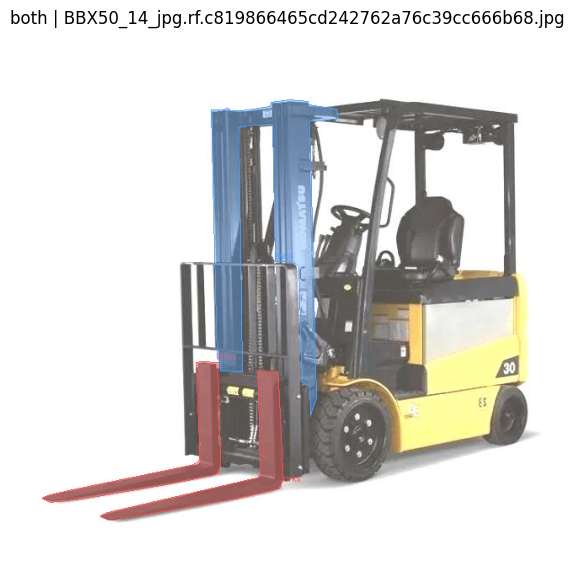

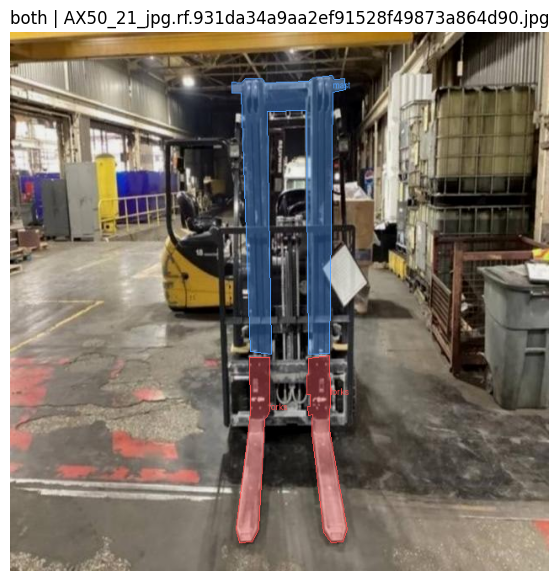

forks_only: 1 images


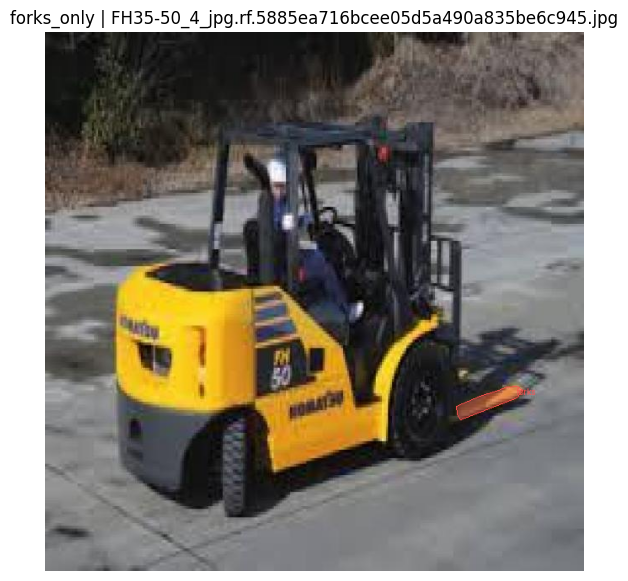

mast_only : 172 images


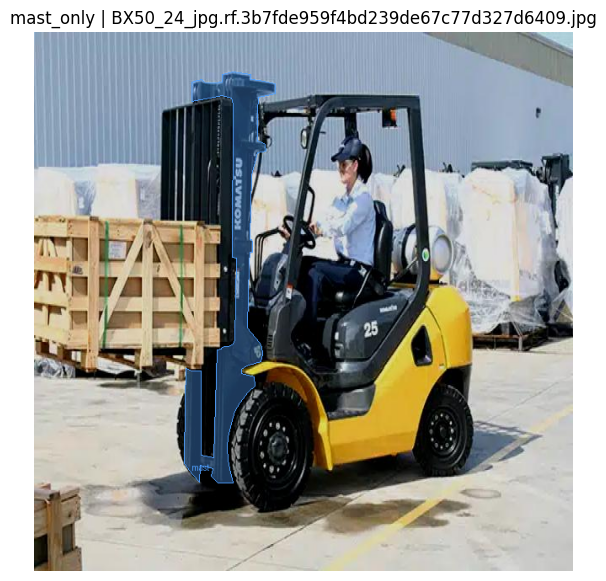

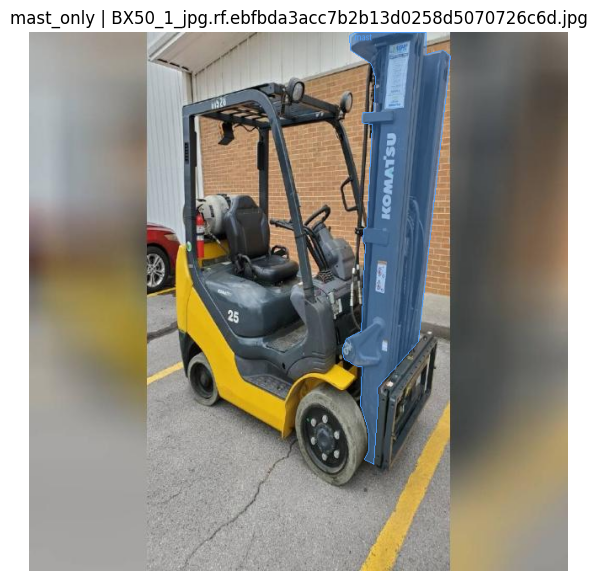

negative  : 53 images


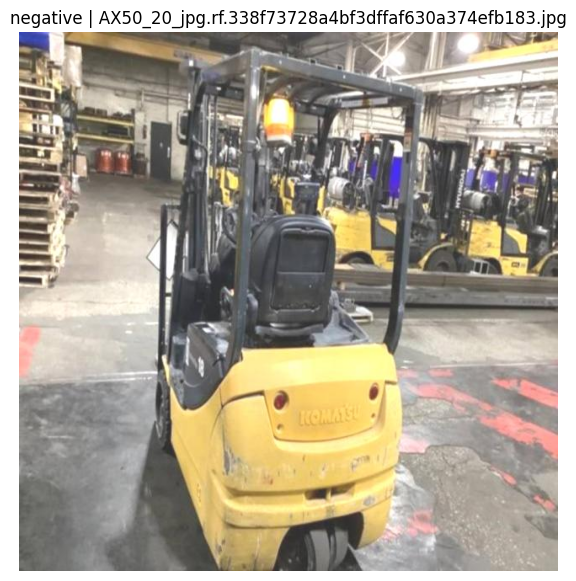

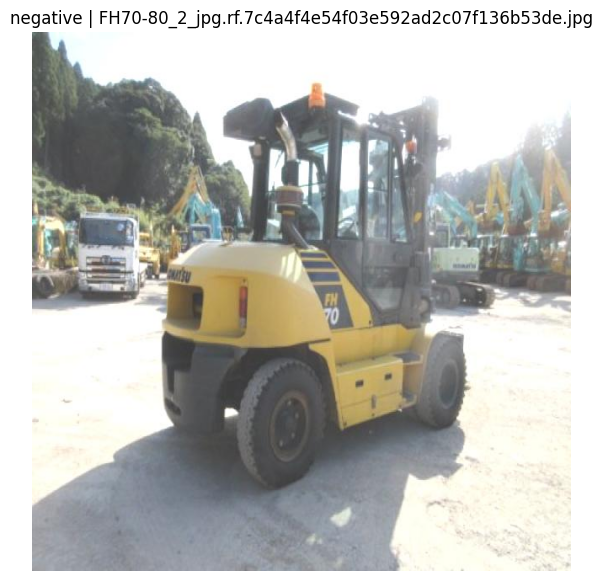

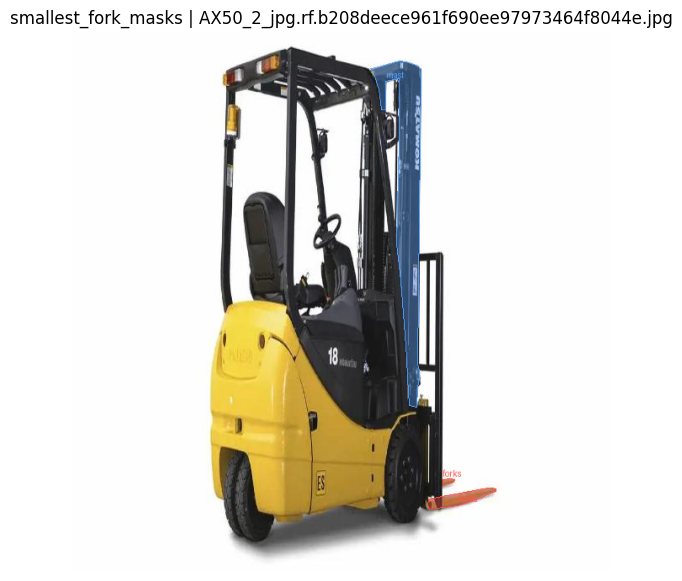

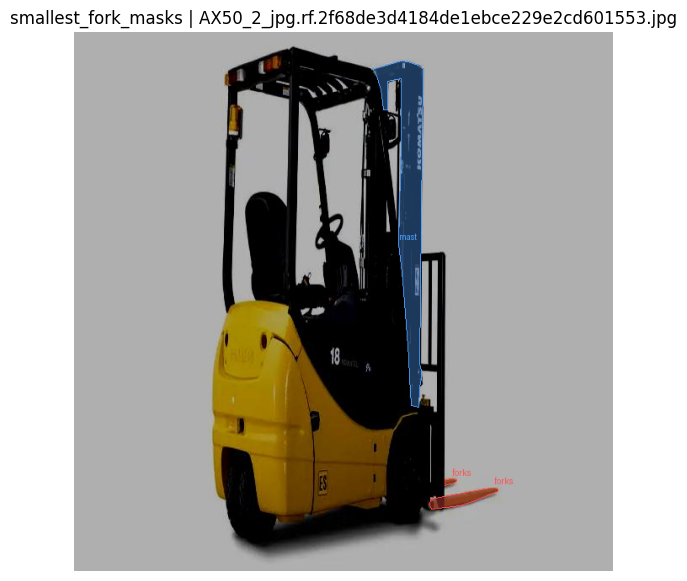

In [10]:
def load_polygons(label_path, width, height):
    polygons = []

    if not label_path.exists():
        return polygons

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            cls = int(parts[0])
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            coords[:, 0] *= width
            coords[:, 1] *= height

            polygons.append((cls, coords))

    return polygons


def show_gt(img_path, category=""):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img, "RGBA")

    label_path = DST_ROOT / img_path.parent.parent.name / "labels" / f"{img_path.stem}.txt"

    colors = {
        0: (255, 80, 80, 90),   # forks
        1: (80, 160, 255, 90),  # mast
    }

    outlines = {
        0: (255, 80, 80, 255),
        1: (80, 160, 255, 255),
    }

    names = {0: "forks", 1: "mast"}

    for cls, points in load_polygons(label_path, img.width, img.height):
        xy = [tuple(map(float, p)) for p in points]

        if len(xy) >= 3:
            draw.polygon(
                xy,
                fill=colors.get(cls, (255, 255, 255, 80)),
                outline=outlines.get(cls, (255, 255, 255, 255)),
            )

            x, y = xy[0]
            draw.text((x, max(0, y - 14)), names[cls], fill=outlines[cls])

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{category} | {img_path.name}" if category else img_path.name)
    plt.show()


train_images = sorted([
    p for p in (DST_ROOT / "train" / "images").iterdir()
    if p.suffix.lower() in IMAGE_EXTS
])

strata = defaultdict(list)
for p in train_images:
    label = DST_ROOT / "train" / "labels" / f"{p.stem}.txt"
    classes = {
        int(line.split()[0])
        for line in label.read_text(encoding="utf-8").splitlines()
        if line.strip()
    }
    category = {
        frozenset({0, 1}): "both",
        frozenset({0}): "forks_only",
        frozenset({1}): "mast_only",
        frozenset(): "negative",
    }.get(frozenset(classes), "unexpected")
    strata[category].append(p)

rng = random.Random(42)
for category in ("both", "forks_only", "mast_only", "negative"):
    candidates = strata.get(category, [])
    print(f"{category:10s}: {len(candidates)} images")
    for img_path in rng.sample(candidates, min(2, len(candidates))):
        show_gt(img_path, category)

fork_area_by_image = []
for image_path in train_images:
    label_path = DST_ROOT / "train" / "labels" / f"{image_path.stem}.txt"
    fork_areas = []
    for cls, points in load_polygons(label_path, 1, 1):
        if cls == 0:
            fork_areas.append(polygon_area(points))
    if fork_areas:
        fork_area_by_image.append((min(fork_areas), image_path))

for _, image_path in sorted(fork_area_by_image, key=lambda item: item[0])[:2]:
    show_gt(image_path, "smallest_fork_masks")

## 11. Cấu hình train

Chọn **YOLO26s-seg** mặc định vì R7 cần mask của `forks` khá mảnh/nhỏ. Dataset chỉ có 266 frame nguồn và đã offline augment brightness/blur, nên baseline giảm augmentation online và dùng early stopping.

- `yolo26n-seg.pt`: nhanh hơn, phù hợp smoke test.
- `yolo26s-seg.pt`: lựa chọn mặc định cho lần train nghiêm túc đầu tiên.

Với dataset nhỏ, dùng transfer learning từ pretrained weights thay vì train from scratch. `IMG_SIZE=640` khớp ảnh đã bị Stretch 640×640; tăng resolution không khôi phục chi tiết đã mất. `MASK_RATIO=2` tạo target mask 320×320 thay vì mặc định 160×160, phù hợp fork mảnh hơn nhưng tốn VRAM hơn.

> Giới hạn dữ liệu: Roboflow v2 dùng **Stretch**, làm méo tỷ lệ ảnh. Với version tiếp theo nên re-export bằng resize giữ aspect ratio (`Fit within`/letterbox) và dùng preprocessing giống pipeline CCTV deployment.

In [11]:
# =========================
# TRAIN CONFIG
# =========================

MODEL_NAME = "yolo26s-seg.pt"
# Đổi thành "yolo26n-seg.pt" nếu muốn test nhanh.
MODEL_PATH_OVERRIDE = None  # Gắn weight vào Kaggle Input nếu Internet tắt.

EPOCHS = 50
IMG_SIZE = 640
MASK_RATIO = 2

# -1 = Ultralytics tự chọn batch dựa trên GPU memory.
BATCH = -1

PATIENCE = 20
ALLOW_CPU_TRAINING = False
DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 4
CACHE = "disk"  # `/kaggle/working` writable; giữ deterministic tốt hơn cache='ram'.
SAVE_PERIOD = 10
FREEZE = None  # A/B thử 10 nếu thấy overfit; baseline giữ toàn bộ backbone trainable.

PROJECT_DIR = resolved_work_root / "r7_runs"
MODEL_TAG = Path(MODEL_NAME).stem.replace("-", "_")
RUN_NAME = f"{MODEL_TAG}_forks_mast_grouped"
CHECKPOINT_METRIC = "metrics/mAP50-95(M)"

if DEVICE == "cpu" and not ALLOW_CPU_TRAINING:
    raise RuntimeError(
        "GPU chưa được bật. Bật Kaggle Accelerator=GPU hoặc chủ động đặt "
        "ALLOW_CPU_TRAINING=True."
    )

print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("Run name:", RUN_NAME)

Model: yolo26s-seg.pt
Device: 0
Run name: yolo26s_seg_forks_mast_grouped


## 12. Pull pretrained YOLO26 segmentation weights

Notebook ưu tiên `MODEL_PATH_OVERRIDE`, sau đó tìm weight cùng tên trong Kaggle Input; nếu không có mới download weight chính thức.

In [12]:
if MODEL_PATH_OVERRIDE is not None:
    MODEL_SOURCE = str(Path(MODEL_PATH_OVERRIDE))
else:
    weight_candidates = sorted(INPUT_ROOT.rglob(MODEL_NAME))
    if len(weight_candidates) > 1:
        raise RuntimeError(f"Có nhiều weight candidate: {weight_candidates}")
    MODEL_SOURCE = str(weight_candidates[0]) if weight_candidates else MODEL_NAME

model = YOLO(MODEL_SOURCE)
if model.task != "segment":
    raise ValueError(f"Model phải là instance segmentation, nhận task={model.task}")

print("Loaded:", MODEL_SOURCE)
print("Task:", model.task)
print("Checkpoint train args (tham khảo):", model.ckpt.get("train_args", {}))

mask_checkpoint_state = {"score": float("-inf"), "epoch": None}

def save_best_mask_checkpoint(trainer):
    raw_score = trainer.metrics.get(CHECKPOINT_METRIC)
    if raw_score is None:
        return
    score = float(raw_score)
    if score <= mask_checkpoint_state["score"]:
        return
    last_path = Path(trainer.last)
    if not last_path.exists():
        return
    target_path = Path(trainer.save_dir) / "weights" / "best_mask.pt"
    shutil.copy2(last_path, target_path)
    mask_checkpoint_state.update(score=score, epoch=trainer.epoch + 1)
    (Path(trainer.save_dir) / "best_mask.json").write_text(
        json.dumps(mask_checkpoint_state, indent=2), encoding="utf-8"
    )
    print(f"Saved best_mask.pt at epoch {trainer.epoch + 1}: {score:.5f}")

model.add_callback("on_model_save", save_best_mask_checkpoint)

Loaded: yolo26s-seg.pt
Task: segment
Checkpoint train args (tham khảo): {'task': 'segment', 'mode': 'train', 'model': 'yolo26s-objv1-seg.pt', 'data': '/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml', 'epochs': 50, 'time': None, 'patience': 100, 'batch': 129, 'imgsz': 640, 'save': True, 'save_period': -1, 'cache': 'disk', 'device': '3,4,5', 'workers': 8, 'project': 'YOLO26', 'name': 'yolo26s-seg-150-1p', 'exist_ok': False, 'pretrained': True, 'optimizer': 'MuSGD', 'verbose': True, 'seed': 0, 'deterministic': True, 'single_cls': False, 'rect': False, 'cos_lr': False, 'close_mosaic': 5, 'resume': False, 'amp': True, 'fraction': 1.0, 'profile': False, 'freeze': None, 'multi_scale': False, 'compile': False, 'semseg_loss': True, 'overlap_mask': True, 'mask_ratio': 1, 'dropout': 0.0, 'val': True, 'split': 'val', 'save_json': True, 'conf': None, 'iou': 0.7, 'max_det': 300, 'half': False, 'dnn': False, 'plots': True, 'source': None, 'vid_stride': 1, 'stream_buffer': False, 'visua

## 13. Train

In [13]:
train_results = model.train(
    data=str(R7_YAML),

    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,
    cache=CACHE,

    patience=PATIENCE,
    optimizer="auto",
    amp=True,
    seed=42,
    deterministic=True,
    freeze=FREEZE,

    # Dataset nhỏ + đã offline augment: giảm augmentation online.
    mosaic=0.5,
    close_mosaic=10,
    mixup=0.0,
    copy_paste=0.0,
    scale=0.25,
    degrees=0.0,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.01,
    hsv_s=0.30,
    hsv_v=0.15,

    mask_ratio=MASK_RATIO,
    overlap_mask=True,
    cos_lr=False,

    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=False,
    save_period=SAVE_PERIOD,

    plots=True,
    verbose=True,
)

RUN_DIR = Path(model.trainer.save_dir)
TRAIN_RUNTIME = {
    "actual_batch_size": int(model.trainer.batch_size),
    "optimizer": type(model.trainer.optimizer).__name__,
    "epochs_completed": int(model.trainer.epoch) + 1,
}
(RUN_DIR / "training_runtime.json").write_text(
    json.dumps(TRAIN_RUNTIME, indent=2), encoding="utf-8"
)
print("Actual run directory:", RUN_DIR)
print("Runtime config:", TRAIN_RUNTIME)

New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/forklift_r7_grouped/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.3, hsv_v=0.15, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=2, max_det=300, mixup

## 14. Xác định checkpoint tốt nhất

Ultralytics mặc định chọn `best.pt` theo fitness kết hợp box + mask. Vì R7 ưu tiên hình học mask, callback phía trên đồng thời lưu `best_mask.pt` theo validation mask mAP50-95. Notebook dùng `best_mask.pt` nếu callback tạo thành công và fallback về `best.pt`. Lưu ý early stopping vẫn theo fitness mặc định; `PATIENCE=20` đủ rộng cho baseline này.

In [14]:
DEFAULT_BEST_PT = RUN_DIR / "weights" / "best.pt"
MASK_BEST_PT = RUN_DIR / "weights" / "best_mask.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
BEST_PT = MASK_BEST_PT if MASK_BEST_PT.exists() else DEFAULT_BEST_PT

print("Run dir :", RUN_DIR)
print("Ultralytics best.pt:", DEFAULT_BEST_PT, DEFAULT_BEST_PT.exists())
print("Mask-selected best :", MASK_BEST_PT, MASK_BEST_PT.exists())
print("Selected checkpoint:", BEST_PT)
print("last.pt :", LAST_PT, LAST_PT.exists())

if not BEST_PT.exists():
    raise FileNotFoundError("Không tìm thấy checkpoint tốt nhất. Kiểm tra log train.")

Run dir : /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped
Ultralytics best.pt: /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped/weights/best.pt True
Mask-selected best : /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped/weights/best_mask.pt True
Selected checkpoint: /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped/weights/best_mask.pt
last.pt : /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped/weights/last.pt True


## 15. Validate `best.pt` trên validation set

In [15]:
best_model = YOLO(str(BEST_PT))

val_metrics = best_model.val(
    data=str(R7_YAML),
    split="val",
    imgsz=IMG_SIZE,
    device=DEVICE,
    workers=WORKERS,
    project=str(RUN_DIR),
    name="validation",
    exist_ok=True,
    plots=True,
)

def report_metrics(metrics, split_name):
    print(f"\n=== {split_name.upper()} BOX METRICS ===")
    print("mAP50-95:", metrics.box.map)
    print("mAP50   :", metrics.box.map50)
    print("mAP75   :", metrics.box.map75)

    print(f"\n=== {split_name.upper()} MASK METRICS ===")
    print("mAP50-95:", metrics.seg.map)
    print("mAP50   :", metrics.seg.map50)
    print("mAP75   :", metrics.seg.map75)

    summary = metrics.summary(decimals=5)
    print("\nPer-class box + mask summary:")
    for row in summary:
        print(row)
    summary_path = Path(metrics.save_dir) / "metrics_summary.json"
    summary_path.write_text(
        metrics.to_json(normalize=True, decimals=5), encoding="utf-8"
    )
    print("Saved:", summary_path)
    return summary

VAL_SUMMARY = report_metrics(val_metrics, "validation")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s-seg summary (fused): 139 layers, 10,366,114 parameters, 0 gradients, 34.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1311.8±149.7 MB/s, size: 47.2 KB)
val: Scanning /kaggle/working/forklift_r7_grouped/valid/labels.cache... 30 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 1.0s
                   all         30         63      0.815      0.619      0.676      0.461      0.801      0.603      0.661      0.375
                 forks         21         37      0.911      0.622      0.677       0.45      0.879       0.59      0.639      0.374
                  mast         26         26       0.72      0.615      0.675      0.471      0.723      0.615      0.682      0.376
Speed: 4.5ms preprocess, 15

## 16. Optional — final evaluation trên test set

In [16]:
# Chỉ chuyển thành True sau khi đã chốt model/hyperparameters trên validation.
RUN_FINAL_TEST = False

if globals().get("RUN_FINAL_TEST", False):
    test_metrics = best_model.val(
        data=str(R7_YAML),
        split="test",
        imgsz=IMG_SIZE,
        device=DEVICE,
        workers=WORKERS,
        project=str(RUN_DIR),
        name="final_test",
        exist_ok=True,
        plots=True,
    )
    TEST_SUMMARY = report_metrics(test_metrics, "test")
else:
    print("Skipped final test. Đặt RUN_FINAL_TEST=True khi cấu hình đã được chốt.")

Skipped final test. Đặt RUN_FINAL_TEST=True khi cấu hình đã được chốt.


## 17. Predict trên held-out validation series

Dùng validation cho kiểm tra định tính và hiệu chỉnh confidence. Không xem test trong quá trình chọn model. `retina_masks=True` trả mask ở kích thước ảnh gốc, phù hợp bước tính fork height phía sau.

In [17]:
PREDICT_IMAGE_DIR = DST_ROOT / "valid" / "images"

predict_images = sorted([
    p for p in PREDICT_IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])
if not predict_images:
    raise FileNotFoundError(f"Không có ảnh validation trong {PREDICT_IMAGE_DIR}")

PRED_DIR = RUN_DIR / "validation_predictions"
if PRED_DIR.parent != RUN_DIR:
    raise RuntimeError(f"Unsafe prediction directory: {PRED_DIR}")
if PRED_DIR.exists():
    shutil.rmtree(PRED_DIR)

pred_results = best_model.predict(
    source=[str(p) for p in predict_images],
    imgsz=IMG_SIZE,
    conf=0.25,
    device=DEVICE,
    retina_masks=True,
    save=True,
    project=str(RUN_DIR),
    name=PRED_DIR.name,
    exist_ok=True,
)

print("Predictions saved to:", PRED_DIR)


0: 640x640 2 forkss, 13.2ms
1: 640x640 (no detections), 13.2ms
2: 640x640 (no detections), 13.2ms
3: 640x640 1 mast, 13.2ms
4: 640x640 2 forkss, 1 mast, 13.2ms
5: 640x640 1 mast, 13.2ms
6: 640x640 1 mast, 13.2ms
7: 640x640 1 forks, 1 mast, 13.2ms
8: 640x640 (no detections), 13.2ms
9: 640x640 (no detections), 13.2ms
10: 640x640 1 forks, 13.2ms
11: 640x640 (no detections), 13.2ms
12: 640x640 (no detections), 13.2ms
13: 640x640 1 mast, 13.2ms
14: 640x640 1 mast, 13.2ms
15: 640x640 2 masts, 13.2ms
16: 640x640 1 mast, 13.2ms
17: 640x640 1 mast, 13.2ms
18: 640x640 (no detections), 13.2ms
19: 640x640 1 mast, 13.2ms
20: 640x640 1 mast, 13.2ms
21: 640x640 2 forkss, 1 mast, 13.2ms
22: 640x640 (no detections), 13.2ms
23: 640x640 2 forkss, 1 mast, 13.2ms
24: 640x640 1 forks, 1 mast, 13.2ms
25: 640x640 (no detections), 13.2ms
26: 640x640 3 forkss, 1 mast, 13.2ms
27: 640x640 2 forkss, 1 mast, 13.2ms
28: 640x640 2 forkss, 1 mast, 13.2ms
29: 640x640 (no detections), 13.2ms
Speed: 1.9ms preprocess, 13

## 18. Hiển thị prediction

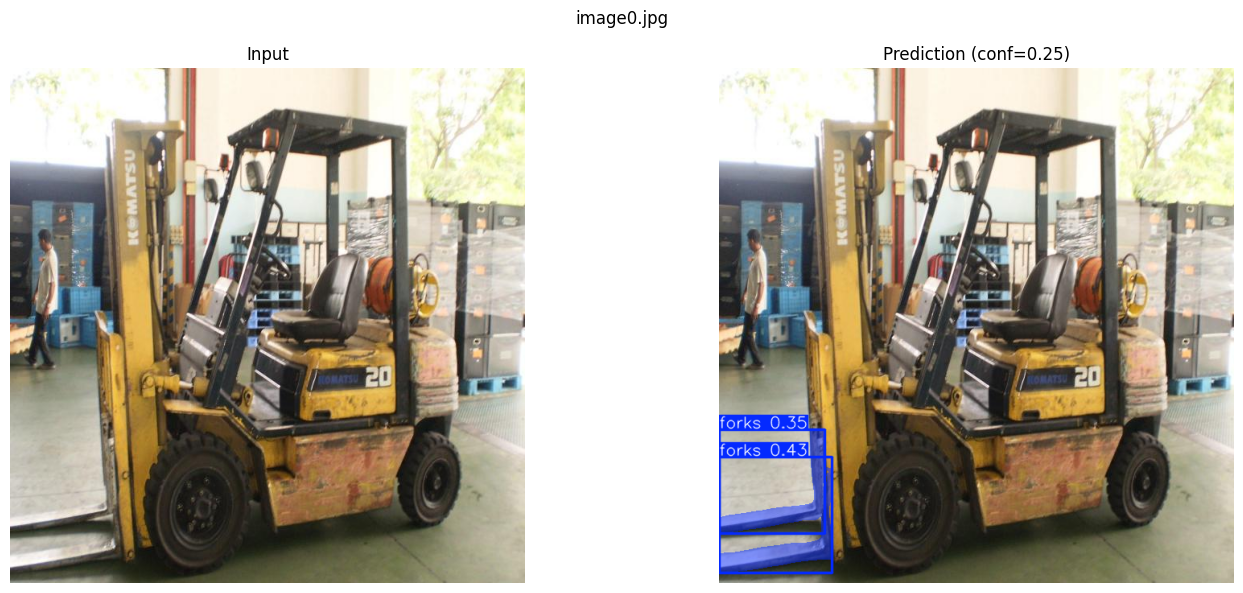

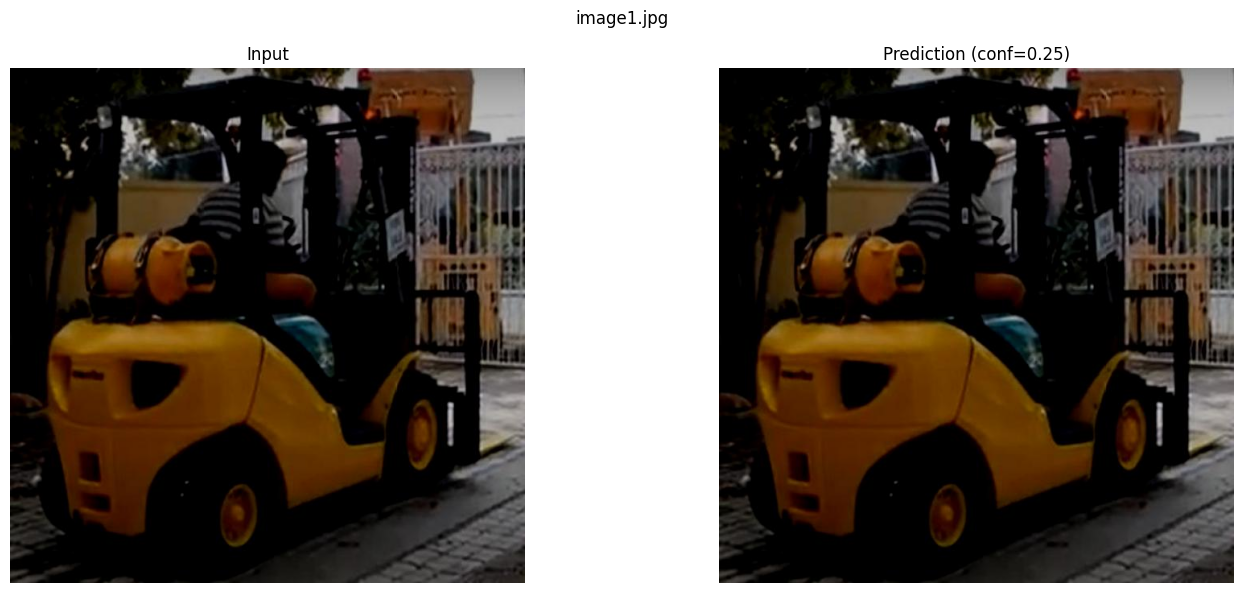

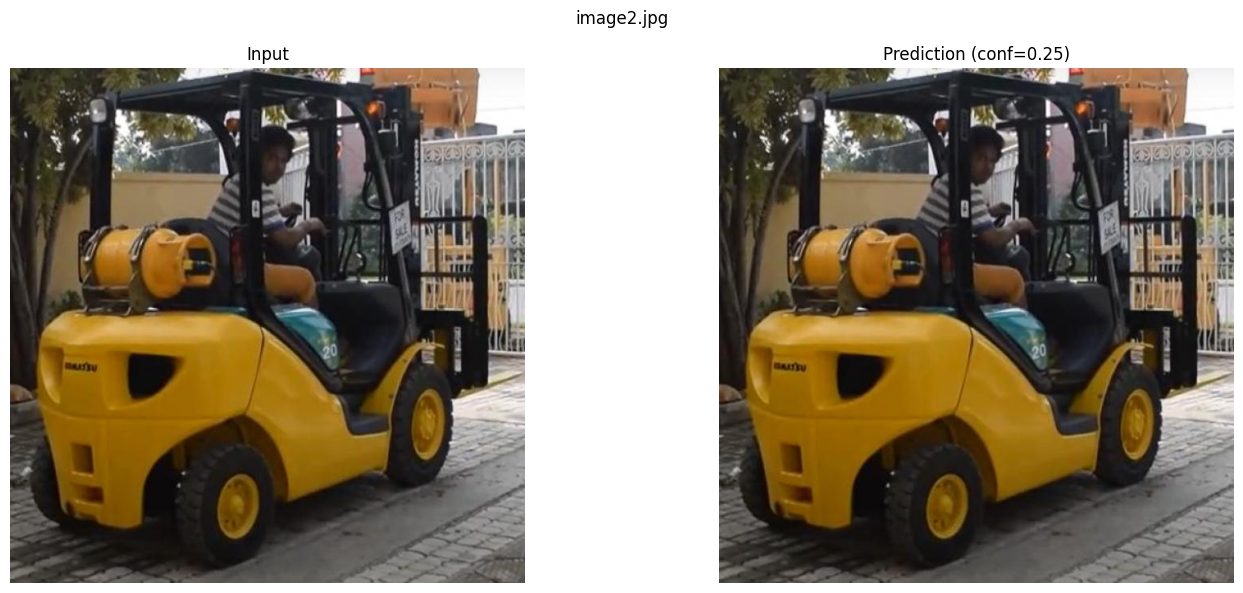

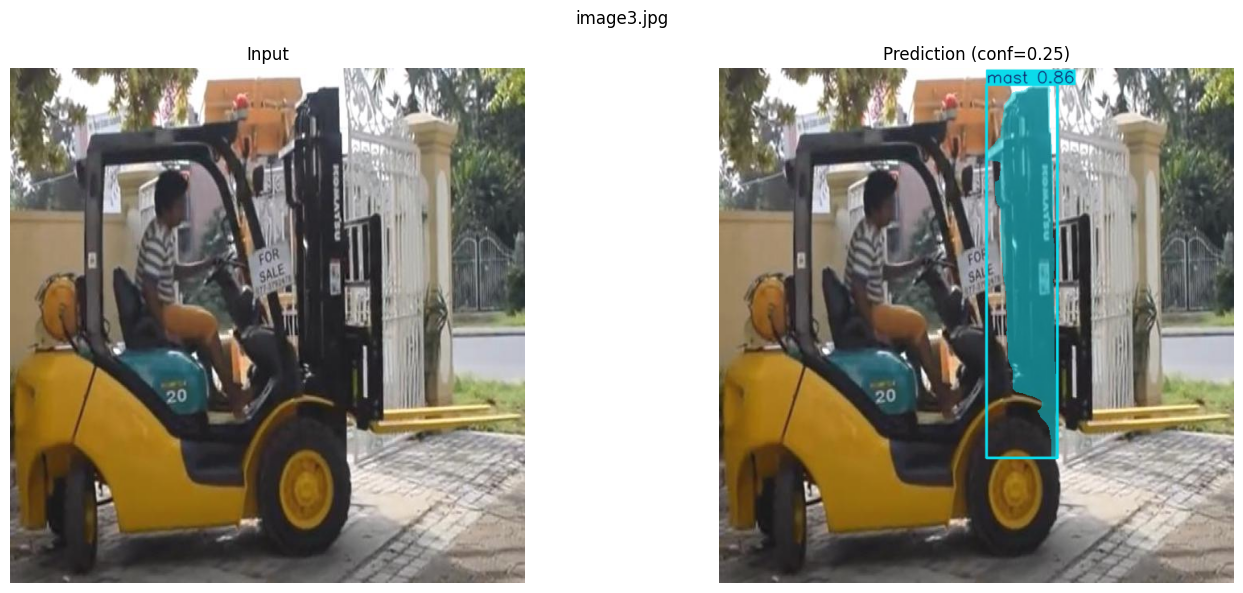

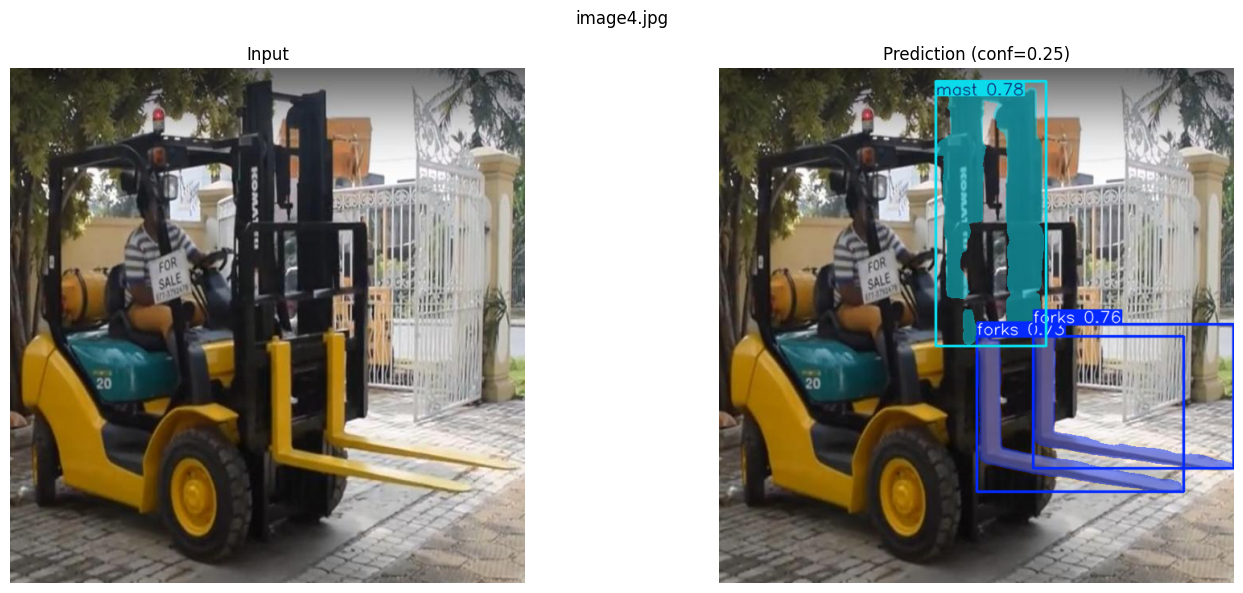

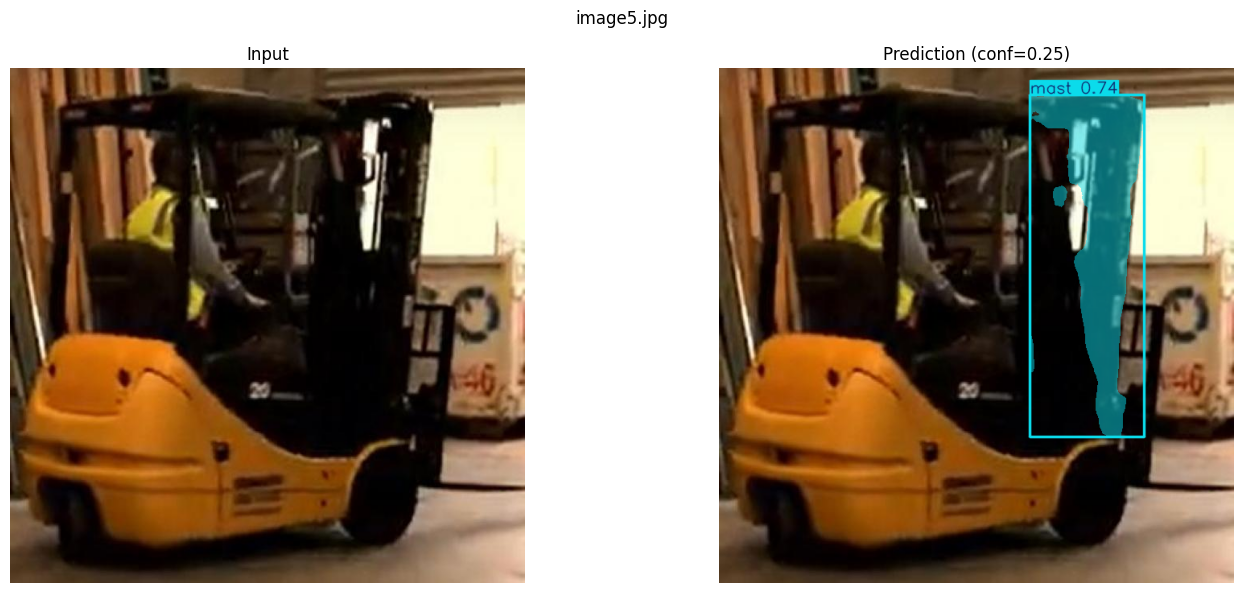

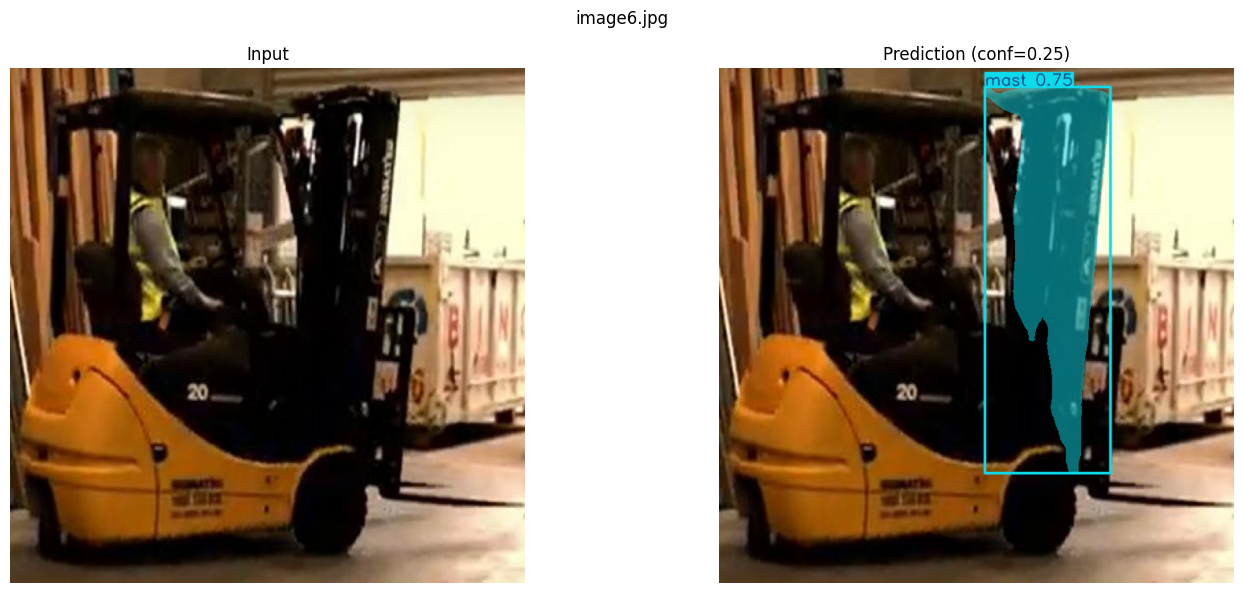

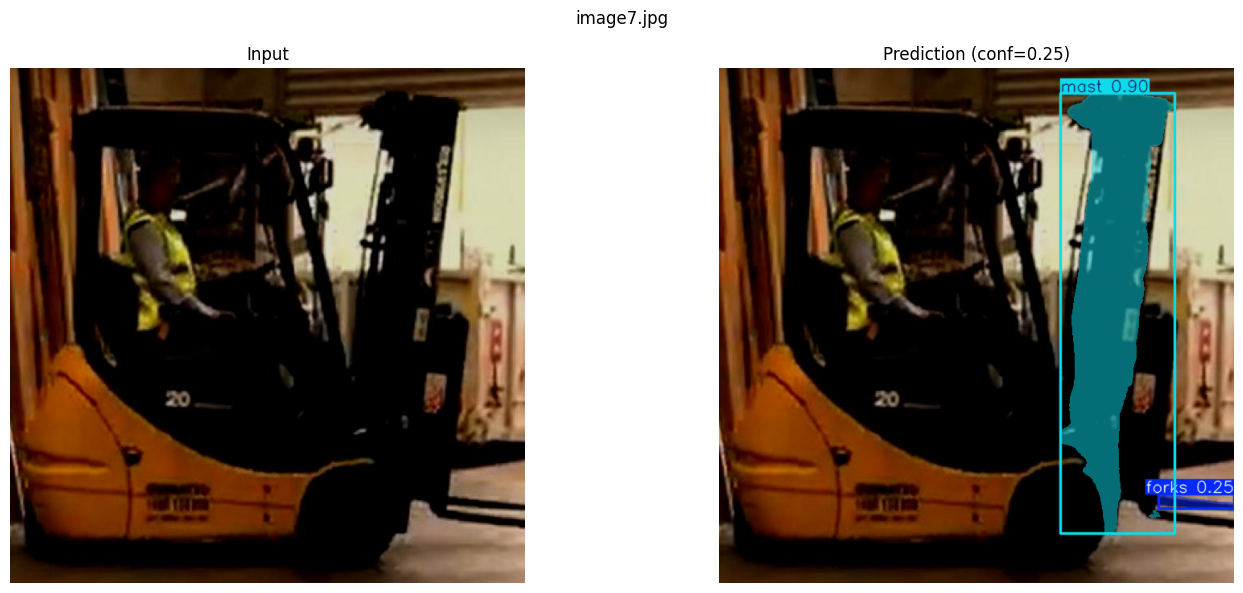

In [18]:
# Hiển thị trực tiếp từ pred_results.
# Không phụ thuộc tên file output mà Ultralytics tạo.

if not pred_results:
    raise RuntimeError("pred_results rỗng. Hãy chạy Cell 17 trước.")

num_show = min(8, len(pred_results))

for result in pred_results[:num_show]:
    source_path = Path(result.path)

    # result.plot() trả về BGR numpy array
    annotated_bgr = result.plot(
        boxes=True,
        labels=True,
        conf=True,
        masks=True,
    )

    # BGR -> RGB cho matplotlib
    annotated_rgb = annotated_bgr[..., ::-1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Input image
    if source_path.exists():
        input_img = Image.open(source_path).convert("RGB")
    else:
        # fallback
        input_img = result.orig_img[..., ::-1]

    axes[0].imshow(input_img)
    axes[0].set_title("Input")

    # Prediction
    axes[1].imshow(annotated_rgb)
    axes[1].set_title("Prediction (conf=0.25)")

    for axis in axes:
        axis.axis("off")

    fig.suptitle(source_path.name)
    plt.tight_layout()
    plt.show()

## 19. Đóng gói model + provenance

Tạo model inference đã strip optimizer, checksum SHA-256 và ZIP gồm config/split manifest/metrics để lần sau biết chính xác model được train từ đâu.

In [19]:
from ultralytics.utils.torch_utils import strip_optimizer

ARTIFACT_NAME = f"r7_{MODEL_TAG}_forks_mast_{RUN_DIR.name}"
ARTIFACT_DIR = (resolved_work_root / ARTIFACT_NAME).resolve()
if ARTIFACT_DIR.parent != resolved_work_root:
    raise RuntimeError(f"Unsafe artifact directory: {ARTIFACT_DIR}")
if ARTIFACT_DIR.exists():
    shutil.rmtree(ARTIFACT_DIR)
ARTIFACT_DIR.mkdir(parents=True)

FINAL_MODEL = ARTIFACT_DIR / f"r7_{MODEL_TAG}_forks_mast_best.pt"
strip_optimizer(BEST_PT, str(FINAL_MODEL))
model_sha256 = hashlib.sha256(FINAL_MODEL.read_bytes()).hexdigest()

artifact_sources = [
    (R7_YAML, "data.yaml"),
    (DST_ROOT / "split_metadata.json", None),
    (DST_ROOT / "split_manifest.csv", None),
    (RUN_DIR / "args.yaml", None),
    (RUN_DIR / "results.csv", None),
    (RUN_DIR / "results.png", None),
    (RUN_DIR / "best_mask.json", None),
    (RUN_DIR / "training_runtime.json", None),
    (Path(val_metrics.save_dir) / "metrics_summary.json", "validation_metrics.json"),
]
if globals().get("RUN_FINAL_TEST", False):
    artifact_sources.append(
        (Path(test_metrics.save_dir) / "metrics_summary.json", "test_metrics.json")
    )
for source_path, target_name in artifact_sources:
    if source_path.exists():
        shutil.copy2(source_path, ARTIFACT_DIR / (target_name or source_path.name))

provenance = {
    "selected_checkpoint": str(BEST_PT),
    "selection_metric": CHECKPOINT_METRIC if MASK_BEST_PT.exists() else "ultralytics_fitness",
    "model_sha256": model_sha256,
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "model_name": MODEL_NAME,
    "class_map": r7_cfg["names"],
    "image_size": IMG_SIZE,
    "mask_ratio": MASK_RATIO,
    "freeze": FREEZE,
}
(ARTIFACT_DIR / "provenance.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8"
)
ARTIFACT_ZIP = Path(shutil.make_archive(str(ARTIFACT_DIR), "zip", ARTIFACT_DIR))
EASY_DOWNLOAD_MODEL = resolved_work_root / FINAL_MODEL.name
shutil.copy2(FINAL_MODEL, EASY_DOWNLOAD_MODEL)

print("Final model:", EASY_DOWNLOAD_MODEL)
print("SHA-256:", model_sha256)
print("Artifact ZIP:", ARTIFACT_ZIP)
print("Size (MB):", round(FINAL_MODEL.stat().st_size / 1024**2, 2))

Optimizer stripped from /kaggle/working/r7_runs/yolo26s_seg_forks_mast_grouped/weights/best_mask.pt, saved as /kaggle/working/r7_yolo26s_seg_forks_mast_yolo26s_seg_forks_mast_grouped/r7_yolo26s_seg_forks_mast_best.pt, 23.4MB
Final model: /kaggle/working/r7_yolo26s_seg_forks_mast_best.pt
SHA-256: 337be25dd39614e2bbcb47a0989a56af0979360a0883382ebca39a3f01609963
Artifact ZIP: /kaggle/working/r7_yolo26s_seg_forks_mast_yolo26s_seg_forks_mast_grouped.zip
Size (MB): 22.32


## 20. Optional — Export ONNX

YOLO26 mặc định export end-to-end, output khác decoder YOLOv8/11 truyền thống và không cần NMS. Nếu downstream hiện tại dùng decoder cũ, đặt `EXPORT_END2END=False`. Luôn smoke-test ONNX trên ảnh validation sau export.

In [20]:
RUN_ONNX_EXPORT = False
EXPORT_END2END = True

if RUN_ONNX_EXPORT:
    export_model = YOLO(str(FINAL_MODEL))
    export_path = export_model.export(
        format="onnx",
        imgsz=IMG_SIZE,
        simplify=True,
        dynamic=False,
        end2end=EXPORT_END2END,
    )
    onnx_model = YOLO(str(export_path), task="segment")
    export_smoke_images = sorted((DST_ROOT / "valid" / "images").glob("*"))
    if not export_smoke_images:
        raise FileNotFoundError("Không có validation image để smoke-test ONNX.")
    _ = onnx_model.predict(
        source=str(export_smoke_images[0]),
        imgsz=IMG_SIZE,
        conf=0.25,
        retina_masks=True,
        verbose=False,
    )
    print("ONNX smoke test OK:", export_path)
else:
    print("Skipped ONNX export.")

Skipped ONNX export.


## 21. Optional — Resume training nếu Kaggle bị ngắt

Trong session mới, hãy attach `last.pt` từ Kaggle Output/Dataset, chạy lại các cell build dataset để khôi phục đúng đường dẫn, rồi đặt `RESUME_FROM`.

In [21]:
RESUME_FROM = None  # Ví dụ: Path("/kaggle/input/r7-checkpoint/last.pt")

if RESUME_FROM is not None:
    resume_path = Path(RESUME_FROM)
    if not resume_path.is_file():
        raise FileNotFoundError(resume_path)
    resume_model = YOLO(str(resume_path))
    resume_model.train(resume=True)
else:
    print("No resume checkpoint configured.")

No resume checkpoint configured.


## Sau khi train xong cần xem gì?

Ưu tiên kiểm tra:

1. **Mask mAP50-95**, mask precision/recall và metric riêng của `forks`/`mast`; không chỉ box mAP.
2. `results.png`, `MaskPR_curve.png`, `MaskF1_curve.png`, `val_batch*_labels.jpg` và `val_batch*_pred.jpg`.
3. Negative samples và các fork mask nhỏ để tìm false-negative annotation.
4. GroupKFold/leave-one-series-out khi cần ước lượng mean±std ổn định hơn.
5. Test cuối trên camera/site CCTV **hoàn toàn ngoài dataset**; group split hiện tại vẫn chỉ có 9 chuỗi.
6. Với mục tiêu R7, bổ sung metric downstream: IoU/Dice, boundary F1, sai số fork tip/relative height và temporal jitter qua video.

Sau khi model detect được `forks` + `mast` ổn định, bước tiếp theo của R7 là dùng mask qua nhiều frame để tính **relative fork height** và suy ra:

```text
RAISING / STATIC / LOWERING
```

Tài liệu đối chiếu: [YOLO26](https://docs.ultralytics.com/models/yolo26/), [YOLO26 training recipe](https://docs.ultralytics.com/guides/yolo26-training-recipe/), [Instance Segmentation](https://docs.ultralytics.com/tasks/segment/), [Train settings](https://docs.ultralytics.com/modes/train/), [Roboflow dataset v2](https://universe.roboflow.com/abdul-nizar-kntam/forklifts-icya5/dataset/2).